Import libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

Connecting to PostgreSQL

In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.append(str(PROJECT_ROOT))

from src.database import get_connection

Loaded data directly from PostgreSQL

In [4]:
query = """
SELECT *
FROM customers;
"""

with get_connection() as connection:
    df = pd.read_sql(query, connection)

print("Dataset shape:", df.shape)

Dataset shape: (7043, 21)


C:\Users\Isha\AppData\Local\Temp\ipykernel_7588\3349138246.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


Basic dataset inspection

In [5]:
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   str    
 1   gender             7043 non-null   str    
 2   senior_citizen     7043 non-null   int64  
 3   partner            7043 non-null   str    
 4   dependents         7043 non-null   str    
 5   tenure             7043 non-null   int64  
 6   phone_service      7043 non-null   str    
 7   multiple_lines     7043 non-null   str    
 8   internet_service   7043 non-null   str    
 9   online_security    7043 non-null   str    
 10  online_backup      7043 non-null   str    
 11  device_protection  7043 non-null   str    
 12  tech_support       7043 non-null   str    
 13  streaming_tv       7043 non-null   str    
 14  streaming_movies   7043 non-null   str    
 15  contract           7043 non-null   str    
 16  paperless_billing  7043 non-null   

In [7]:
df.isnull().sum()

customer_id          0
gender               0
senior_citizen       0
partner              0
dependents           0
tenure               0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
contract             0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
churn                0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

Separate numeric and categorical columns

In [9]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

print("Numeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numeric columns:
['senior_citizen', 'tenure', 'monthly_charges', 'total_charges']

Categorical columns:
['customer_id', 'gender', 'partner', 'dependents', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'churn']


What is Overall Churn ?

In [10]:
churn_counts = df["churn"].value_counts()

print(churn_counts)

churn
No     5174
Yes    1869
Name: count, dtype: int64


In [11]:
churn_percent = (
    df["churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(churn_percent)

churn
No    73.46
Yes   26.54
Name: proportion, dtype: float64


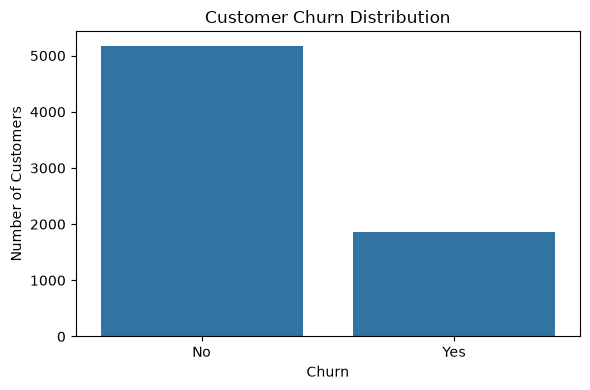

In [12]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

Does contract type relate to churn?

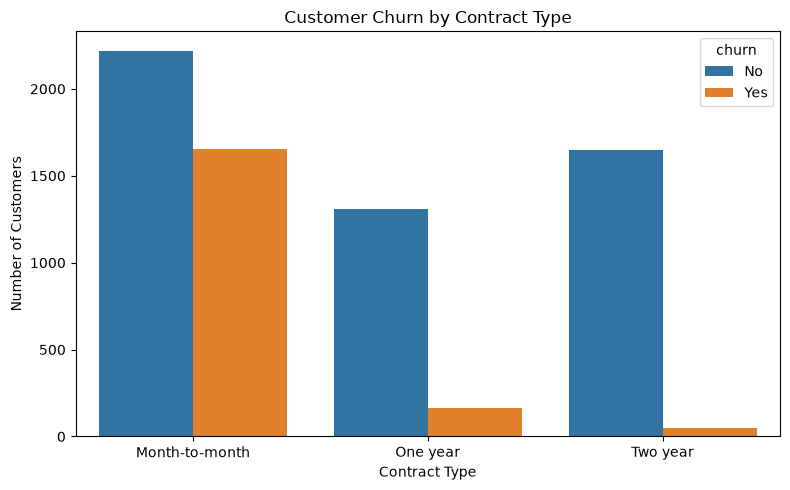

In [13]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="contract",
    hue="churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [14]:
contract_churn = (
    pd.crosstab(
        df["contract"],
        df["churn"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

contract_churn

churn,No,Yes
contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


How does tenure affect churn?

In [15]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=[
        "0-1 Year",
        "1-2 Years",
        "2-4 Years",
        "4+ Years"
    ]
)

In [16]:
df["tenure_group"].value_counts().sort_index()

tenure_group
0-1 Year     2186
1-2 Years    1024
2-4 Years    1594
4+ Years     2239
Name: count, dtype: int64

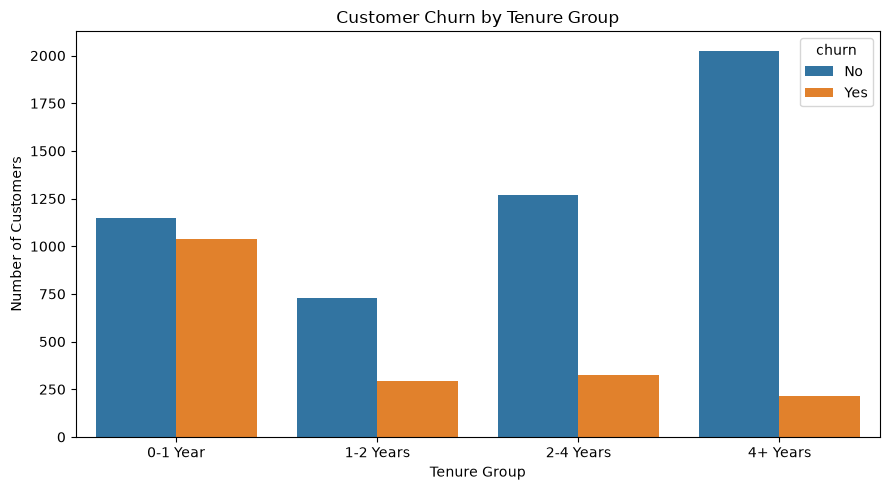

In [17]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="tenure_group",
    hue="churn"
)

plt.title("Customer Churn by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [18]:
tenure_churn = (
    pd.crosstab(
        df["tenure_group"],
        df["churn"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

tenure_churn

churn,No,Yes
tenure_group,,
0-1 Year,52.56,47.44
1-2 Years,71.29,28.71
2-4 Years,79.61,20.39
4+ Years,90.49,9.51


Are monthly charges different for churned customers?

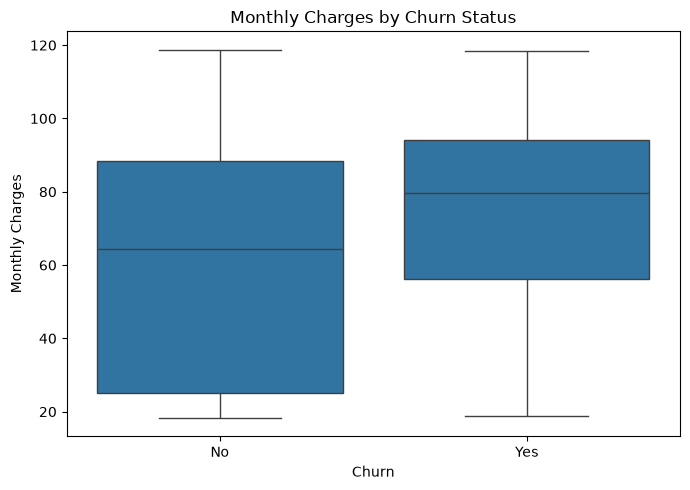

In [19]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="churn",
    y="monthly_charges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

In [20]:
df.groupby("churn")["monthly_charges"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
churn,,,,,
No,5174,61.27,64.43,18.25,118.75
Yes,1869,74.44,79.65,18.85,118.35


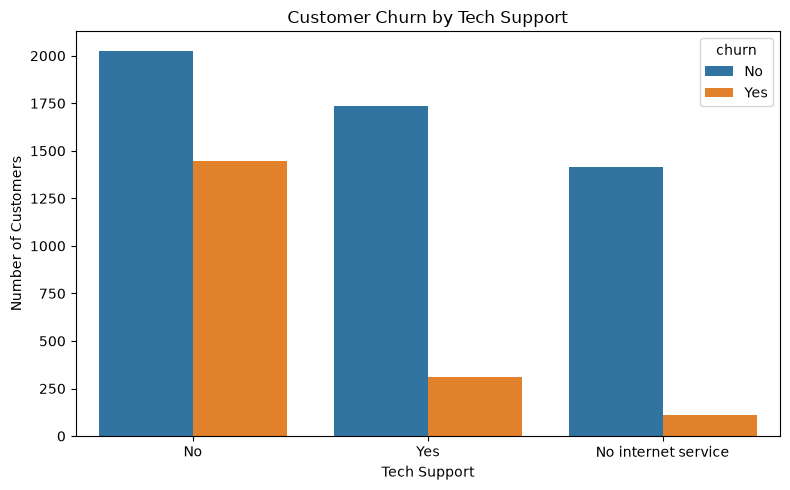

In [21]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="tech_support",
    hue="churn"
)

plt.title("Customer Churn by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [22]:
pd.crosstab(
    df["tech_support"],
    df["churn"],
    normalize="index"
).mul(100).round(2)

churn,No,Yes
tech_support,,
No,58.36,41.64
No internet service,92.60,7.40
Yes,84.83,15.17


Internet Service vs Churn

Tech support and churn

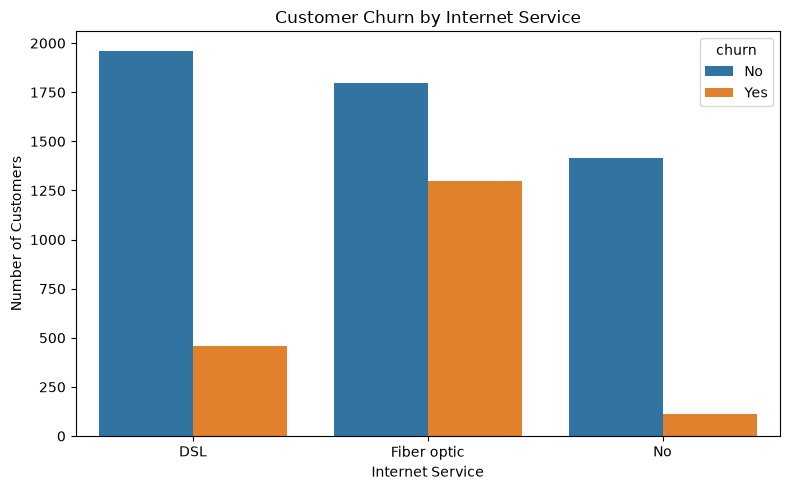

In [23]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="internet_service",
    hue="churn"
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [24]:
internet_churn = (
    pd.crosstab(
        df["internet_service"],
        df["churn"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

internet_churn

churn,No,Yes
internet_service,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


Payment Method vs Churn

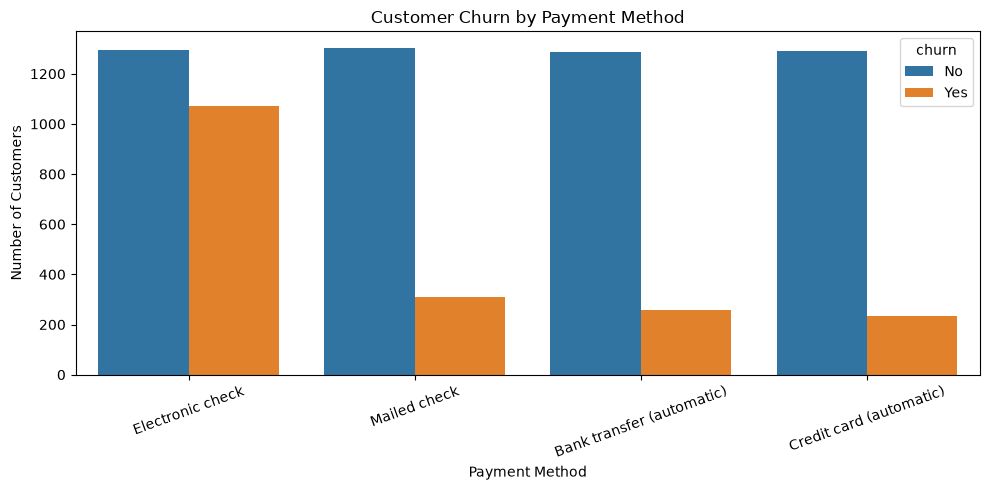

In [25]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="payment_method",
    hue="churn"
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [26]:
payment_churn = (
    pd.crosstab(
        df["payment_method"],
        df["churn"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

payment_churn

churn,No,Yes
payment_method,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


Online Security vs Churn

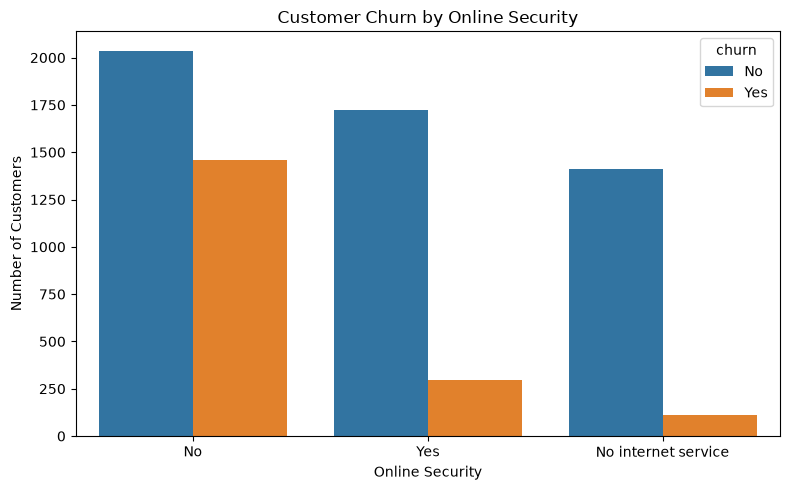

In [27]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="online_security",
    hue="churn"
)

plt.title("Customer Churn by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [28]:
security_churn = (
    pd.crosstab(
        df["online_security"],
        df["churn"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

security_churn

churn,No,Yes
online_security,,
No,58.23,41.77
No internet service,92.60,7.40
Yes,85.39,14.61


Churn by Senior Citizen Status

In [30]:
df["senior_citizen_group"] = df["senior_citizen"].map({
    0: "Non-Senior Citizen",
    1: "Senior Citizen"
})

Churn by Senior Citizen Status

In [31]:
df["senior_citizen_group"] = df["senior_citizen"].map({
    0: "Non-Senior Citizen",
    1: "Senior Citizen"
})

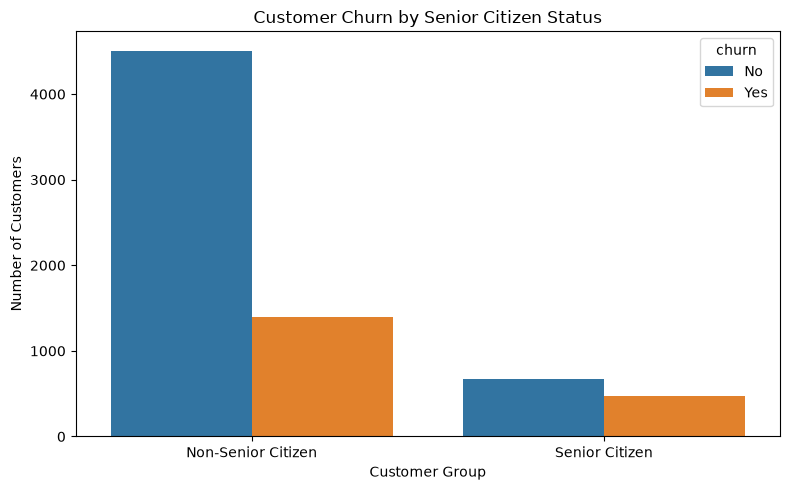

In [32]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="senior_citizen_group",
    hue="churn"
)

plt.title("Customer Churn by Senior Citizen Status")
plt.xlabel("Customer Group")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

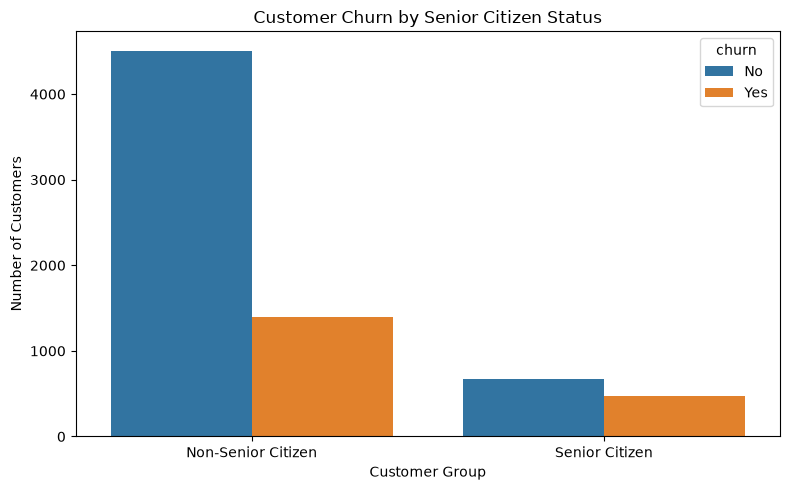

In [33]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="senior_citizen_group",
    hue="churn"
)

plt.title("Customer Churn by Senior Citizen Status")
plt.xlabel("Customer Group")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

Churn by Gender

In [34]:
gender_churn = (
    pd.crosstab(
        df["gender"],
        df["churn"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

gender_churn

churn,No,Yes
gender,,
Female,73.08,26.92
Male,73.84,26.16


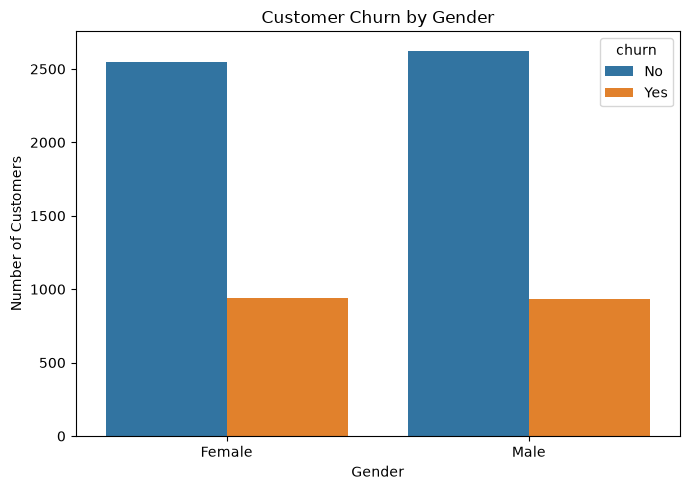

In [35]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="gender",
    hue="churn"
)

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

Revenue analysis

In [36]:
revenue_summary = (
    df.groupby("churn")
      .agg(
          customers=("customer_id", "count"),
          avg_monthly_charges=("monthly_charges", "mean"),
          median_monthly_charges=("monthly_charges", "median"),
          avg_total_charges=("total_charges", "mean"),
          total_monthly_charges=("monthly_charges", "sum")
      )
      .round(2)
)

revenue_summary

,customers,avg_monthly_charges,median_monthly_charges,avg_total_charges,total_monthly_charges
churn,,,,,
No,5174,61.27,64.43,2549.91,316985.75
Yes,1869,74.44,79.65,1531.80,139130.85


Visualize monthly charges

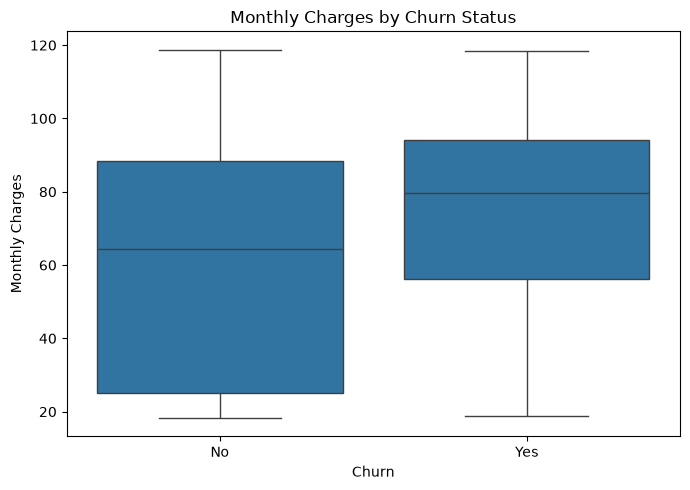

In [37]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="churn",
    y="monthly_charges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

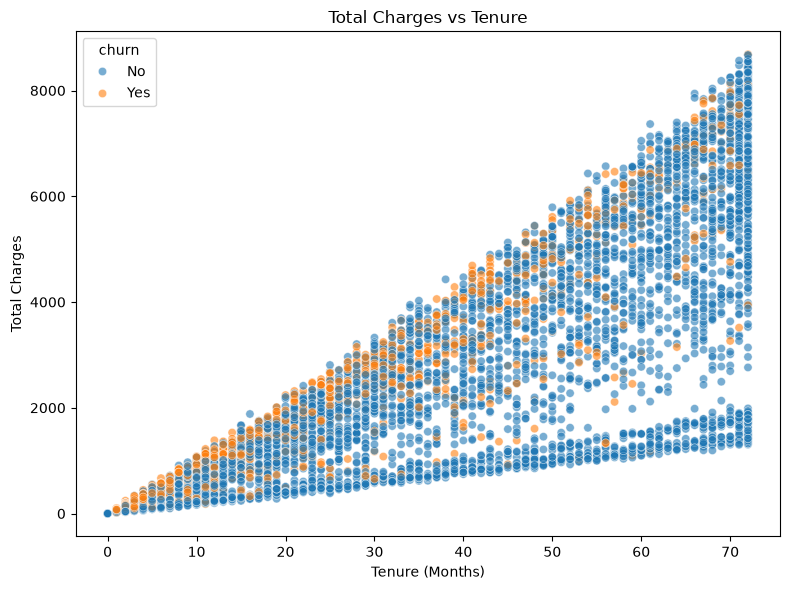

In [38]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="tenure",
    y="total_charges",
    hue="churn",
    alpha=0.6
)

plt.title("Total Charges vs Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Total Charges")

plt.tight_layout()
plt.show()

Correlation analysis

In [39]:
numeric_cols = [
    "senior_citizen",
    "tenure",
    "monthly_charges",
    "total_charges"
]

correlation_matrix = df[numeric_cols].corr()

correlation_matrix

,senior_citizen,tenure,monthly_charges,total_charges
senior_citizen,1.00,0.02,0.22,0.10
tenure,0.02,1.00,0.25,0.83
monthly_charges,0.22,0.25,1.00,0.65
total_charges,0.10,0.83,0.65,1.00


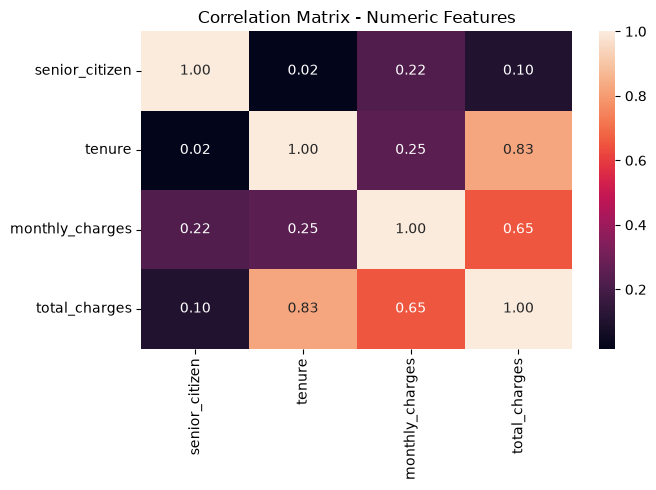

In [40]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix - Numeric Features")

plt.tight_layout()
plt.show()

Create a customer risk profile

In [43]:
new_monthly = df[
    (df["tenure"] <= 12) &
    (df["contract"] == "Month-to-month")
]

print("Customers:", len(new_monthly))

print(
    "Churn rate:",
    round(
        new_monthly["churn"].eq("Yes").mean() * 100,
        2
    ),
    "%"
)

Customers: 1994
Churn rate: 51.35 %


In [44]:
high_risk_segment = df[
    (df["tenure"] <= 12) &
    (df["contract"] == "Month-to-month") &
    (df["monthly_charges"] >= 70)
]

print("Customers:", len(high_risk_segment))

print(
    "Churn rate:",
    round(
        high_risk_segment["churn"].eq("Yes").mean() * 100,
        2
    ),
    "%"
)

Customers: 860
Churn rate: 69.19 %


In [45]:
eda_summary = {
    "overall_churn_rate": round(
        df["churn"].eq("Yes").mean() * 100,
        2
    ),

    "avg_tenure_churned": round(
        df.loc[df["churn"] == "Yes", "tenure"].mean(),
        2
    ),

    "avg_tenure_retained": round(
        df.loc[df["churn"] == "No", "tenure"].mean(),
        2
    ),

    "avg_monthly_charges_churned": round(
        df.loc[df["churn"] == "Yes", "monthly_charges"].mean(),
        2
    ),

    "avg_monthly_charges_retained": round(
        df.loc[df["churn"] == "No", "monthly_charges"].mean(),
        2
    )
}

eda_summary

{'overall_churn_rate': np.float64(26.54),
 'avg_tenure_churned': np.float64(17.98),
 'avg_tenure_retained': np.float64(37.57),
 'avg_monthly_charges_churned': np.float64(74.44),
 'avg_monthly_charges_retained': np.float64(61.27)}